In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
folder_name = "/home/ildefons/yaf310/examples/ayafs/FederatedLearning/results/"
module_file_name = "sim_trace.csv"
link_file_name = "sim_trace_link.csv"

In [3]:
df_module = pd.read_csv(folder_name+module_file_name)
df_link = pd.read_csv(folder_name+link_file_name)

In [4]:
df_module.columns

Index(['id', 'type', 'app', 'module', 'message', 'DES.src', 'DES.dst',
       'TOPO.src', 'TOPO.dst', 'module.src', 'service', 'time_in', 'time_out',
       'time_emit', 'time_reception', 'in_buffer_size_des', 'qos'],
      dtype='object')

In [5]:
df = df_module

df_module["time_service"] = df.time_out - df.time_in

total_time = 10000

values = df_module.groupby("DES.dst").time_service.agg("sum")/10000 * 100

values

#values[id_entity] / total_time

DES.dst
1     0.015804
2     3.995600
3     1.685400
4    96.123086
5    96.220279
Name: time_service, dtype: float64

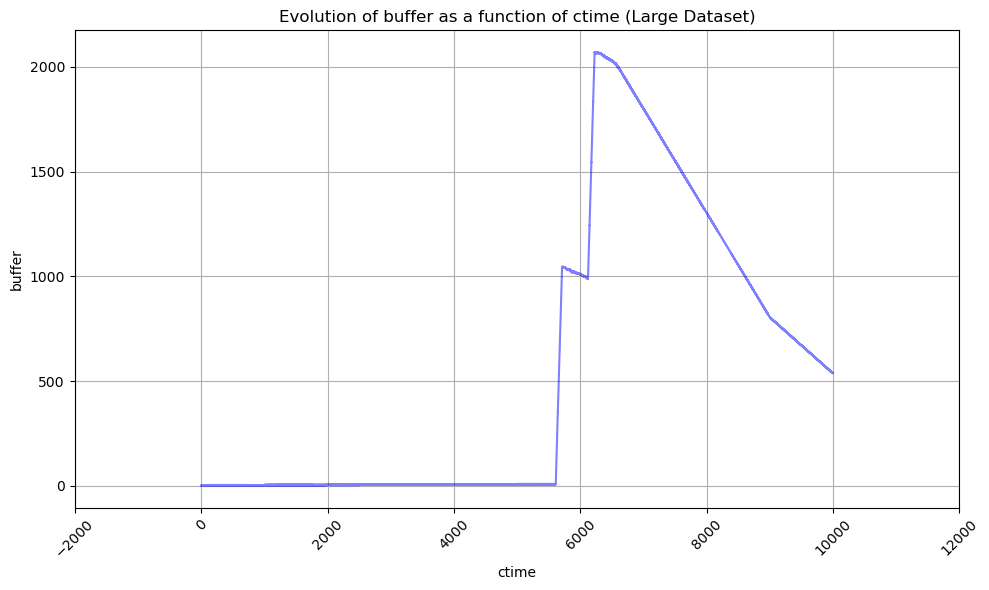

In [6]:
plt.figure(figsize=(10, 6))
df = df_link
plt.plot(df['ctime'], df['buffer'], linestyle='-', color='b', alpha=0.5)  # No marker for large data
# For step-like behavior (if buffer changes discretely):
# plt.step(df['ctime'], df['buffer'], where='post', color='b', alpha=0.5)
plt.xlabel('ctime')
plt.ylabel('buffer')
plt.title('Evolution of buffer as a function of ctime (Large Dataset)')
plt.grid(True)

# Optimize x-axis ticks for readability
plt.xticks(ticks=plt.xticks()[0], rotation=45)  # Rotate labels if needed
plt.tight_layout()

#Note:

# Suddenly at ctime=802, M.Bs start being input in the network
#    Exactly a burst of 802 M.Bs generated by ServiceA
#    then it starts acting normally by showing 1)M.A,2)M.B...
#  


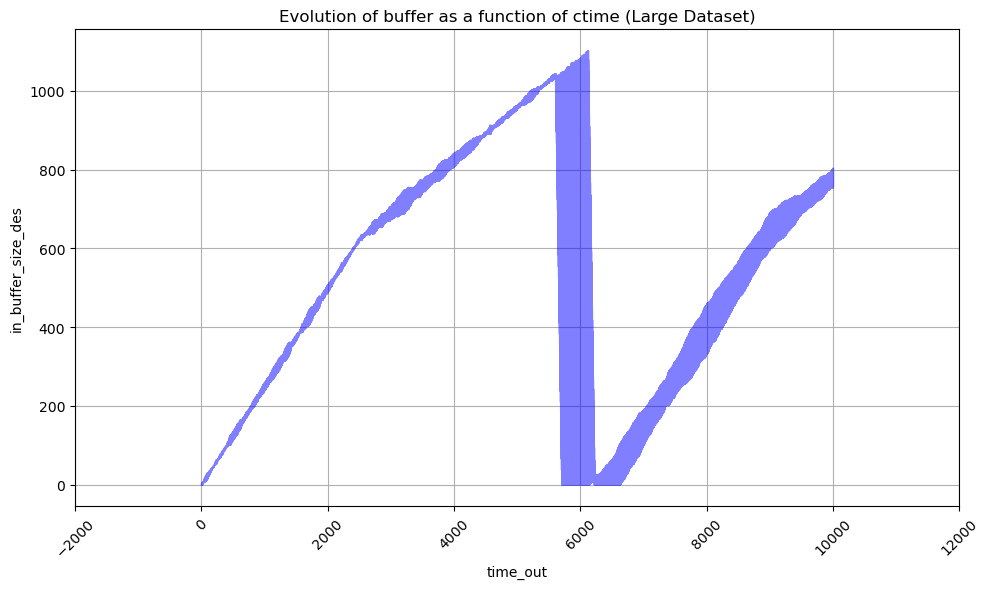

In [7]:
# plot together the evolution of "buffer" (whole network) and "in_buffer_size_des" (ServiceA)
# Create the plot
plt.figure(figsize=(10, 6))
df = df_module[df_module.message=="M1"]
plt.plot(df['time_out'], df['in_buffer_size_des'], linestyle='-', color='b', alpha=0.5)  # No marker for large data
# For step-like behavior (if buffer changes discretely):
# plt.step(df['ctime'], df['buffer'], where='post', color='b', alpha=0.5)
plt.xlabel('time_out')
plt.ylabel('in_buffer_size_des')
plt.title('Evolution of buffer as a function of ctime (Large Dataset)')
plt.grid(True)

# Optimize x-axis ticks for readability
plt.xticks(ticks=plt.xticks()[0], rotation=45)  # Rotate labels if needed
plt.tight_layout()#Note:myactions2(action_id=1, node_id=self.node_id)mean_time_reception = df[df["DES.dst"]==id].time_reception.mean()
  

# Suddenly at ctime=802, M.Bs start being input in the network
#    Exactly a burst of 802 M.Bs generated by ServiceA
#    then it starts acting normally by showing 1)M.A,2)M.B...
#  